# SQL code


select createdon_date,
sum(seats) as seats
from booking_v bv 
where status_name in ('Paid','Confirmed','Refunded')  and createdon_date between '2014-01-01' and '2025-04-15'
GROUP by createdon_date


### EDA

In [819]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from datetime import datetime
pd.options.display.float_format = '{:.2f}'.format

from itertools import combinations
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima_model import ARIMA
import statsmodels.api as sm
import statsmodels.tsa.api as smt

In [821]:
import pandas as pd
data = pd.read_csv('/Users/gulzhankumar/Downloads/booking.csv')
data.head()

,createdon_date,seats
0,2014-01-24,1
1,2014-01-25,1
2,2014-01-26,2
3,2014-01-27,6
4,2014-01-29,1


In [409]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4033 entries, 0 to 4032
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   createdon_date  4033 non-null   object
 1   seats           4033 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 63.1+ KB


In [411]:
data.shape

(4033, 2)

In [823]:
data['createdon_date'] = pd.to_datetime(data['createdon_date'])
data.set_index('createdon_date', inplace=True)

data.sort_index(inplace=True)

data.head()


,seats
createdon_date,
2014-01-24,1
2014-01-25,1
2014-01-26,2
2014-01-27,6
2014-01-29,1


In [415]:
data.tail()

,seats
createdon_date,
2025-04-11,29460
2025-04-12,28120
2025-04-13,30879
2025-04-14,31767
2025-04-15,22203


In [417]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4033 entries, 2014-01-24 to 2025-04-15
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   seats   4033 non-null   int64
dtypes: int64(1)
memory usage: 63.0 KB


In [419]:
data.describe()

,seats
count,4033.00
mean,5315.23
std,8302.70
min,1.00
25%,270.00
50%,1558.00
75%,5448.00
max,41098.00


In [421]:
data.isna().sum()

seats    0
dtype: int64

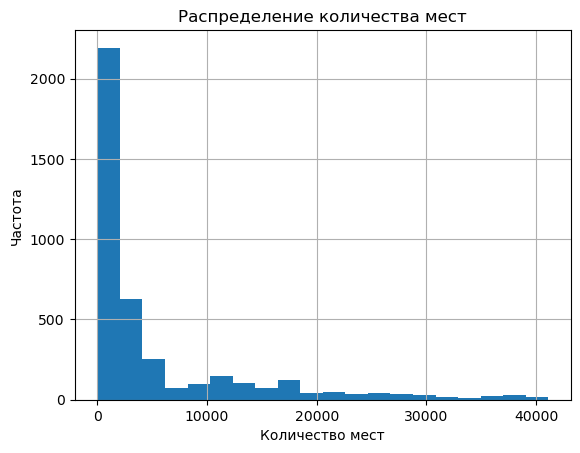

In [423]:
import matplotlib.pyplot as plt

# Построим гистограмму по значению `seats`
data['seats'].hist(bins=20)
plt.title('Распределение количества мест')
plt.xlabel('Количество мест')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

### ARIMA

In [425]:
def test_stationarity(timeseries):
    #Determing rolling statistics
    MA = timeseries.rolling(window=365).mean()
    MSTD = timeseries.rolling(window=365).std()

    #Plot rolling statistics:
    plt.figure(figsize=(15,5))
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(MA, color='red', label='Rolling Mean')
    std = plt.plot(MSTD, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

In [427]:
def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    with plt.style.context(style):
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))

        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title('Time Series Analysis Plots\n Dickey-Fuller: p={0:.5f}'.format(p_value))
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()
        plt.show()

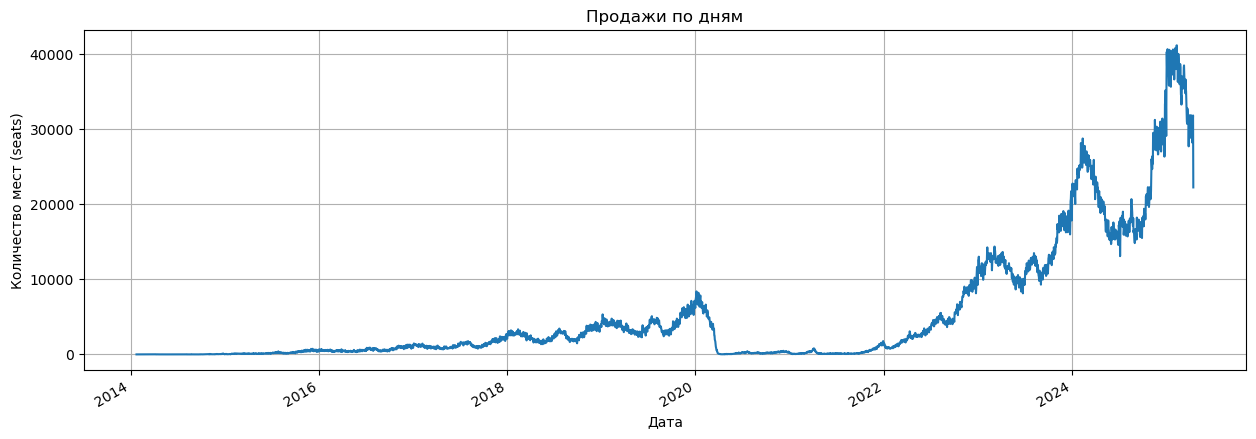

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
data['seats'].plot()
plt.title('Продажи по дням')
plt.xlabel('Дата')
plt.ylabel('Количество мест (seats)')
plt.grid(True)
plt.show()


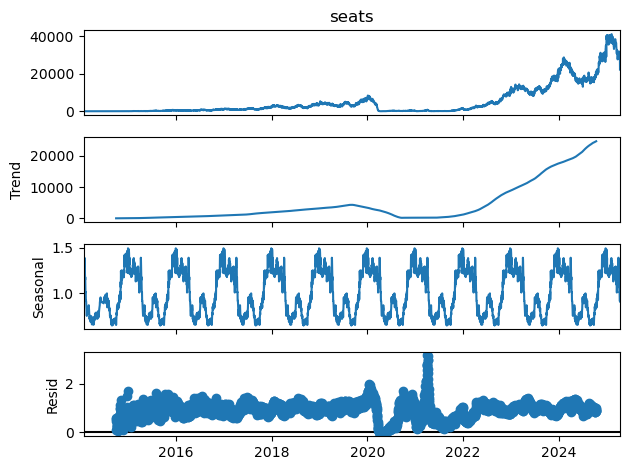

In [429]:
dec = sm.tsa.seasonal_decompose(data['seats'],period = 365, model = 'multiplicative').plot()
plt.show()

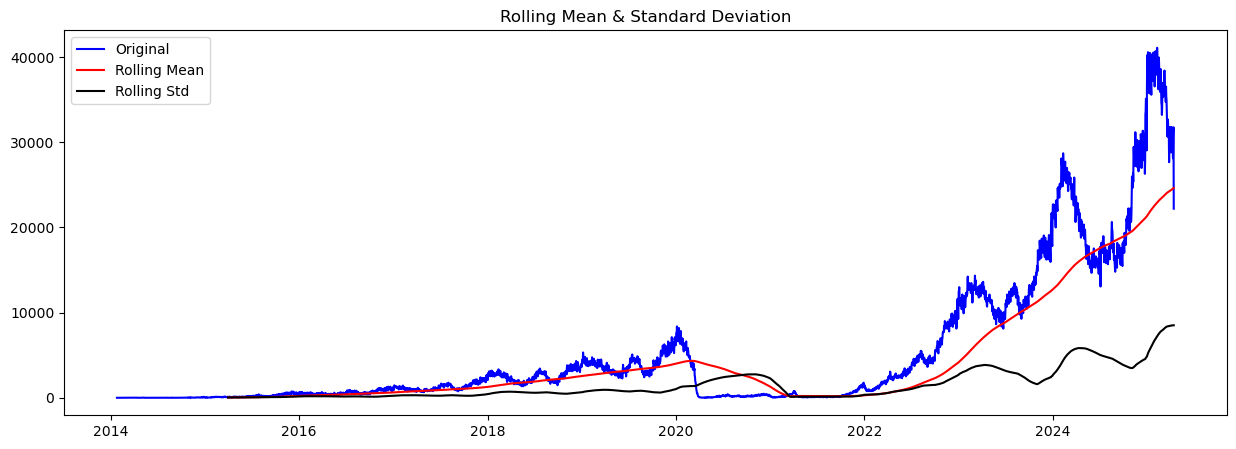

Results of Dickey-Fuller Test:
Test Statistic                  -1.94
p-value                          0.31
#Lags Used                      31.00
Number of Observations Used   4001.00
Critical Value (1%)             -3.43
Critical Value (5%)             -2.86
Critical Value (10%)            -2.57
dtype: float64


In [431]:
test_stationarity(data['seats'])

Результаты теста Дики-Фуллера:

Test Statistic: -1.94

p-value: 0.31

Critical Value (5%): -2.86

Вывод: Поскольку p-value = 0.31 > 0.05, => нестационарный ряд

In [433]:
dd = data.copy()
dd['diff_1'] = dd.diff(1)



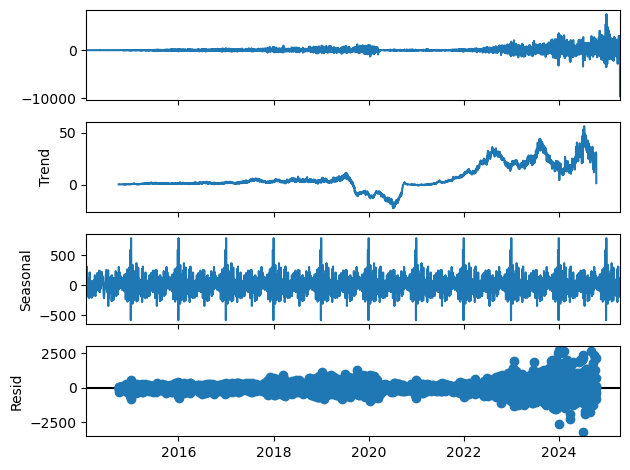

In [435]:
data_diff = data.diff(periods = 1)
data_diff = data_diff.dropna()

dec = sm.tsa.seasonal_decompose(data_diff,period = 365).plot()
plt.show()

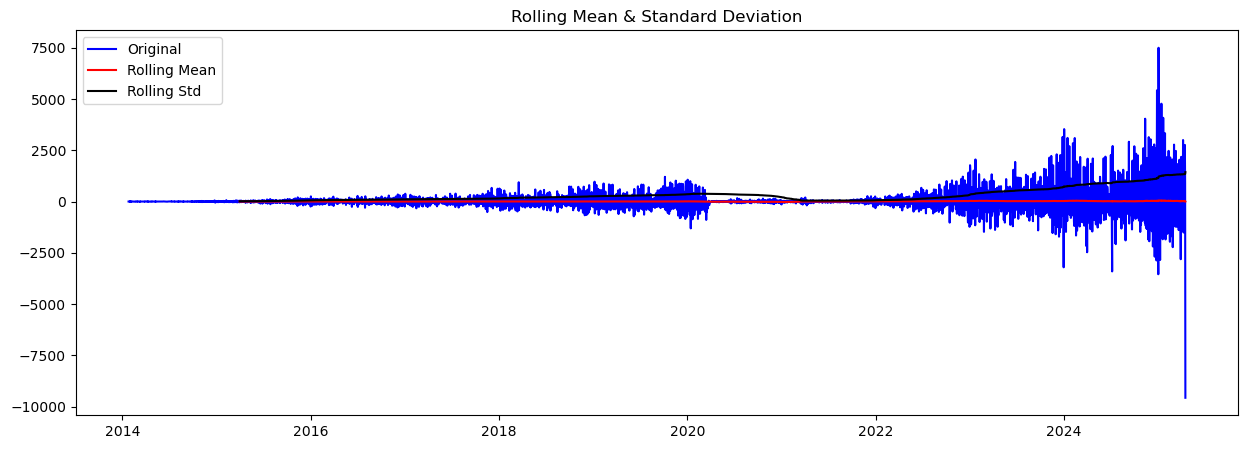

Results of Dickey-Fuller Test:
Test Statistic                  -5.96
p-value                          0.00
#Lags Used                      31.00
Number of Observations Used   4000.00
Critical Value (1%)             -3.43
Critical Value (5%)             -2.86
Critical Value (10%)            -2.57
dtype: float64


In [437]:
test_stationarity(data_diff)

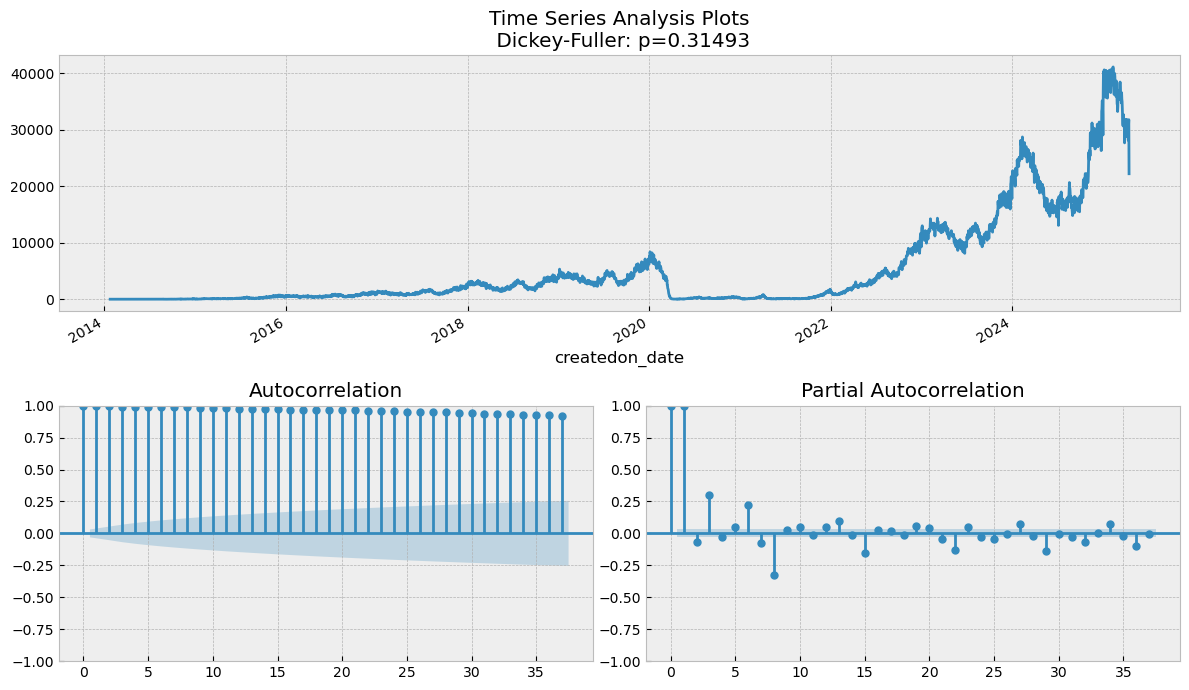

In [439]:
tsplot(data['seats'])

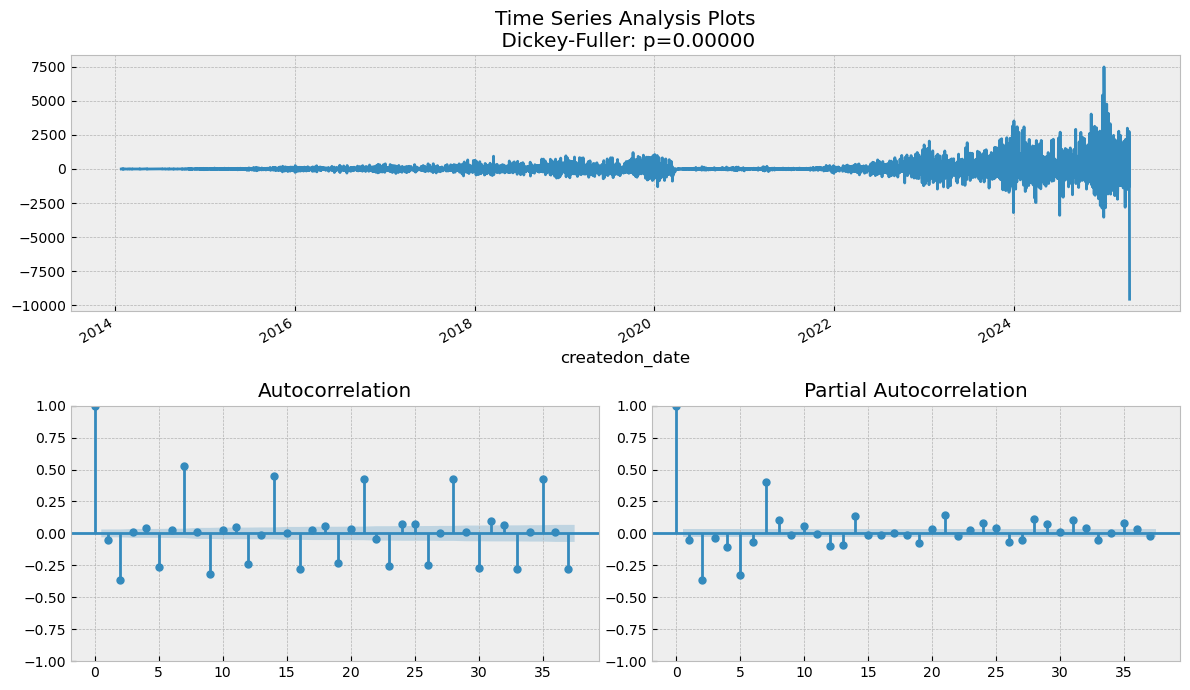

In [170]:
tsplot(data_diff['seats'])

In [441]:
import statsmodels
model = statsmodels.tsa.arima.model.ARIMA(data['seats'],order = (2,2,2))
model_fit = model.fit()
print(model_fit.summary())

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  seats   No. Observations:                 4033
Model:                 ARIMA(2, 2, 2)   Log Likelihood              -30776.025
Date:                Tue, 29 Apr 2025   AIC                          61562.050
Time:                        17:40:45   BIC                          61593.559
Sample:                             0   HQIC                         61573.215
                               - 4033                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3694      0.011     33.292      0.000       0.348       0.391
ar.L2         -0.3431      0.006    -53.175      0.000      -0.356      -0.330
ma.L1         -1.5265      0.012   -126.491      0.0

In [561]:
size = int(len(data) - 365)
train, test = data['seats'][0:size], data['seats'][size:len(data)]

print('\t ARIMA MODEL : In- Sample Forecasting \n')

history = [x for x in train]
predictions = []

for t in range(len(test)):

    model = statsmodels.tsa.arima.model.ARIMA(history, order=(2,2,2))
    model_fit = model.fit()

    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(float(yhat))

    obs = test[t]
    history.append(obs)

    print('predicted = %f, expected = %f' % (yhat, obs))

	 ARIMA MODEL : In- Sample Forecasting 



/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/var/folders/r2/5qjgyz6d3fl5x00dm2qg95w00000gn/T/ipykernel_31648/992462587.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  obs = test[t]


predicted = 21030.639687, expected = 21042.000000
predicted = 20544.287943, expected = 20683.000000
predicted = 20513.064403, expected = 20792.000000
predicted = 20663.407702, expected = 19332.000000
predicted = 19435.026121, expected = 18803.000000
predicted = 19293.082360, expected = 20902.000000
predicted = 20824.629139, expected = 20488.000000


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


predicted = 19818.997197, expected = 19663.000000
predicted = 19400.954389, expected = 20642.000000
predicted = 20385.355989, expected = 19939.000000
predicted = 19552.515787, expected = 19046.000000


...

predicted = 36775.026309, expected = 36038.000000
predicted = 36365.660352, expected = 36355.000000


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


predicted = 36905.283906, expected = 35573.000000
predicted = 35906.557308, expected = 34724.000000
predicted = 35332.355431, expected = 36549.000000


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


predicted = 36888.540607, expected = 35380.000000
predicted = 35175.771686, expected = 34963.000000
predicted = 35264.591753, expected = 33709.000000
predicted = 34202.193067, expected = 32319.000000
predicted = 33310.820662, expected = 30986.000000
predicted = 32205.249898, expected = 30655.000000
predicted = 31818.017816, expected = 32693.000000
predicted = 32988.699796, expected = 32242.000000
predicted = 31944.193161, expected = 31113.000000
predicted = 30973.725136, expected = 30973.000000
predicted = 31138.816165, expected = 30474.000000
predicted = 30550.194563, expected = 27663.000000
predicted = 28472.152008, expected = 29491.000000
predicted = 30204.427384, expected = 31671.000000
predicted = 31007.097819, expected = 31795.000000
predicted = 30518.514871, expected = 30389.000000
predicted = 29651.185504, expected = 31200.000000
predicted = 30970.827016, expected = 29944.000000
predicted = 30001.818782, expected = 28888.000000
predicted = 29119.325427, expected = 28805.000000


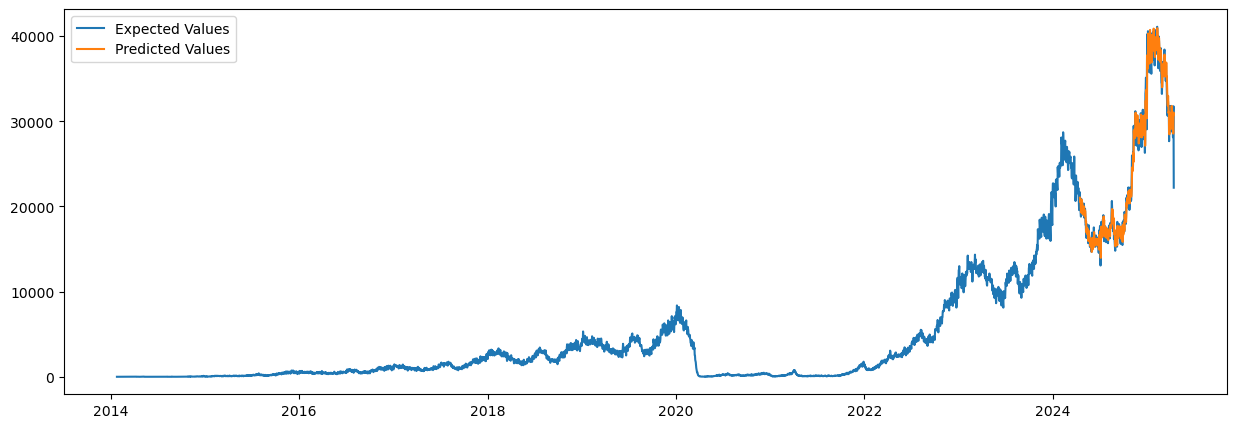

In [563]:
predictions_series = pd.Series(predictions, index = test.index)
fig,ax = plt.subplots(nrows = 1,ncols = 1,figsize = (15,5))

plt.subplot(1,1,1)
plt.plot(data['seats'],label = 'Expected Values')
plt.plot(predictions_series,label = 'Predicted Values');
plt.legend(loc="upper left")
plt.show()

In [565]:
error = np.sqrt(mean_squared_error(test,predictions))
print('Test RMSE: %.4f' % error)

Test RMSE: 1312.0065


In [567]:
from sklearn.metrics import mean_absolute_percentage_error

mean_absolute_percentage_error(test,predictions)

0.038439652443074054

In [569]:
from sklearn.metrics import r2_score

r2_score(test,predictions)

0.9761858970649867

In [571]:
# Обучаем модель на всей выборке
final_model = statsmodels.tsa.arima.model.ARIMA(data['seats'], order=(2, 2, 2))
final_fit = final_model.fit()

forecast_year = final_fit.forecast(steps=365)


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [573]:
last_date = data.index[-1]

index_year = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=365, freq='D')

forecast_month_series = pd.Series(forecast_month.values, index=index_month)
forecast_quarter_series = pd.Series(forecast_quarter.values, index=index_quarter)
forecast_year_series = pd.Series(forecast_year.values, index=index_year)


ValueError: Length of values (1) does not match length of index (30)

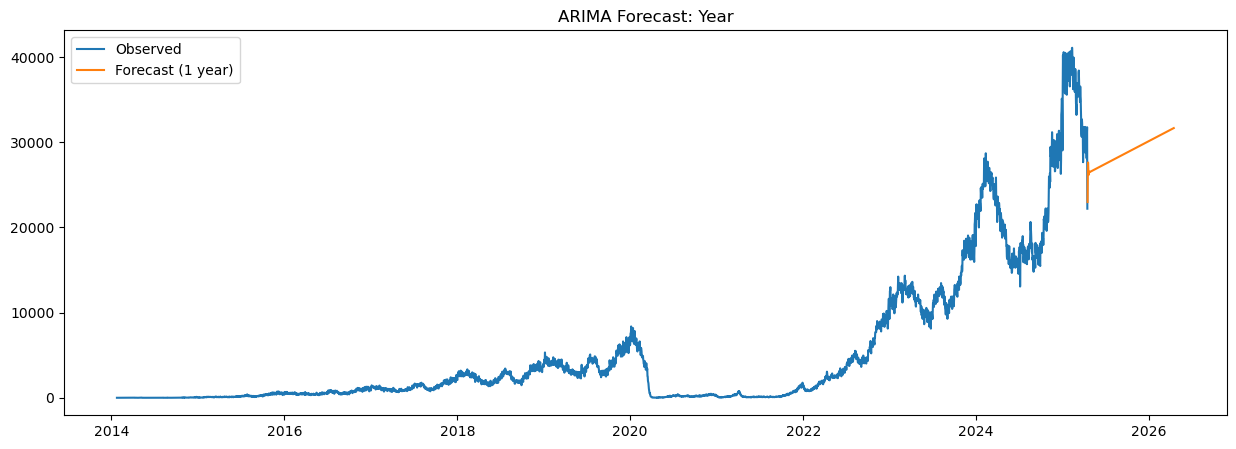

In [555]:
plt.figure(figsize=(15, 5))
plt.plot(data['seats'], label='Observed')
plt.plot(forecast_year_series, label='Forecast (1 year)', alpha=1)
plt.legend()
plt.title('ARIMA Forecast: Year')
plt.show()


# SARIMA monthly

In [588]:
monthly_data = data['seats'].resample('MS').sum()

In [657]:
monthly_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 136 entries, 2014-01-31 to 2025-04-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   y       136 non-null    int64
dtypes: int64(1)
memory usage: 6.2 KB


In [659]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_data['y'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -1.7734338555099742
p-value: 0.3937285069714748


In [661]:
monthly_diff = monthly_data.diff().dropna()

# Для сезонности (предположим годовая сезонность = 12 месяцев)
monthly_seasonal_diff = monthly_diff.diff(12).dropna()


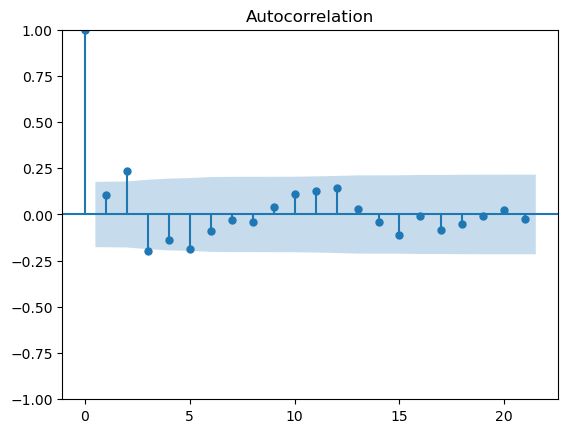

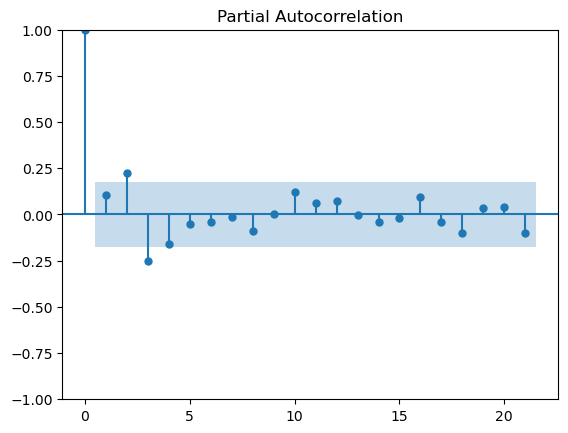

In [663]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(monthly_seasonal_diff)
plot_pacf(monthly_seasonal_diff)
plt.show()


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.08683D+00    |proj g|=  7.20578D-02

At iterate    5    f=  9.07912D+00    |proj g|=  3.45217D-03

At iterate   10    f=  9.07431D+00    |proj g|=  6.39681D-02

At iterate   15    f=  9.07164D+00    |proj g|=  2.92465D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     16     21      1     0     0   2.692D-05   9.072D+00
  F =   9.0716435007778902     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


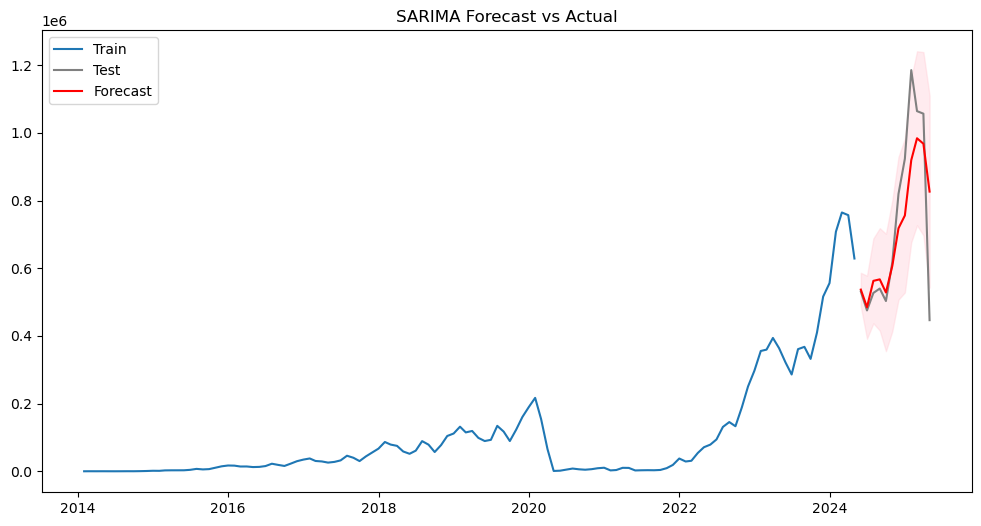

In [683]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Разделение данных на train и test
train = monthly_data.iloc[:-12]
test = monthly_data.iloc[-12:]

# Обучение модели SARIMA
model = SARIMAX(train,
                order=(1,1,1),
                seasonal_order=(1,1,1,12),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit()

# Прогноз на 12 месяцев
forecast = results.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()



# Визуализация
plt.figure(figsize=(12,6))
plt.plot(train.index, train['y'], label='Train')
plt.plot(test.index, test['y'], label='Test', color='gray')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.title('SARIMA Forecast vs Actual')
plt.legend()
plt.show()


In [685]:
# Оценка модели
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
mape = mean_absolute_percentage_error(test, forecast_mean)
r2 = r2_score(test, forecast_mean)

print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2%}')
print(f'R^2: {r2:.4f}')

RMSE: 150169.99
MAPE: 14.62%
R^2: 0.6604


### Prophet monthly for year



In [825]:
# Сначала агрегация по месяцам
monthly_data = data.resample('MS').sum()

# Преобразуем в формат Prophet
df = monthly_data.reset_index()
df.columns = ['ds', 'y']  # Prophet требует именно такие имена


In [827]:
test_months = 12
train_df = df[:-test_months]
test_df = df[-test_months:]


In [829]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'  # можно заменить на 'additive' и сравнить
)

model.fit(train_df)


09:29:14 - cmdstanpy - INFO - Chain [1] start processing
09:29:14 - cmdstanpy - INFO - Chain [1] done processing


In [831]:
# Создаем даты на период длины test
future = model.make_future_dataframe(periods=12, freq='MS')

# Строим прогноз
forecast = model.predict(future)

# Сохраняем только нужные колонки
forecast_result = forecast[['ds', 'yhat']]

# Приводим тест к тому же виду (по датам)
test_df = test_df.set_index('ds')
forecast_result = forecast_result.set_index('ds')


In [833]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Берём только пересекающиеся даты
y_true = test_df['y']
y_pred = forecast_result.loc[test_df.index]['yhat']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.4f}')


MAE: 75348.94
RMSE: 137564.91
R²: 0.7151


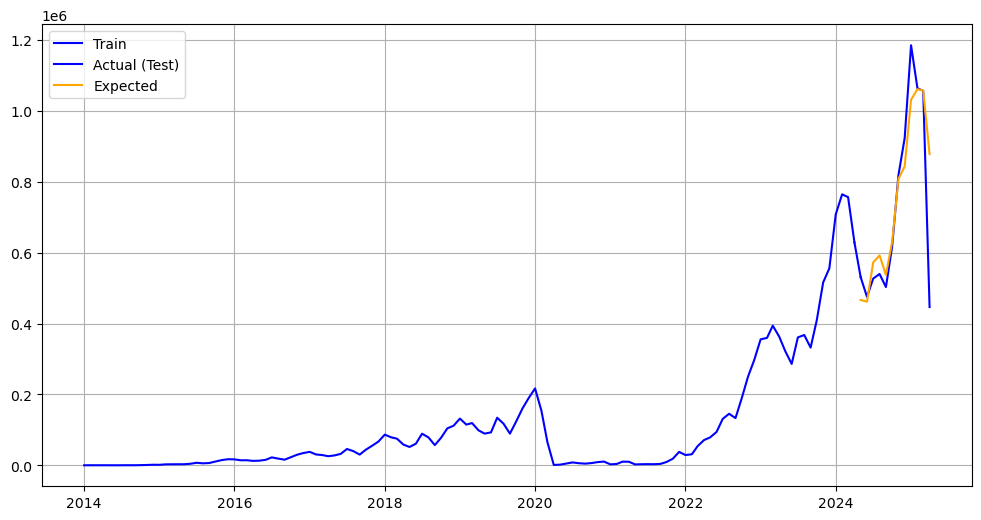

In [835]:
plt.figure(figsize=(12,6))

# 1) train
plt.plot(train_df['ds'], train_df['y'], label='Train', color='blue')

# 2) линия-связка: соединяем (последняя точка train) → (первая точка test)
x_link = [train_df['ds'].iloc[-1], test_df.index[0]]
y_link = [train_df['y'].iloc[-1], test_df['y'].iloc[0]]
plt.plot(x_link, y_link, color='blue')

# 3) test фактическое
plt.plot(test_df.index, test_df['y'], label='Actual (Test)', color='blue')

# 4) forecast
plt.plot(test_df.index, y_pred, label='Expected', color='orange')

plt.legend(); plt.grid(True); plt.show()


In [837]:
from prophet import Prophet

# Обучаем модель на всей выборке
full_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'  # Или 'additive' по желанию
)

full_model.fit(df)  # df должен быть с колонками ['ds', 'y']

# Прогноз на 1 год (12 месяцев)
future_year = full_model.make_future_dataframe(periods=12, freq='MS')
forecast_year = full_model.predict(future_year)[['ds', 'yhat']].tail(12)


09:29:30 - cmdstanpy - INFO - Chain [1] start processing
09:29:30 - cmdstanpy - INFO - Chain [1] done processing


09:29:35 - cmdstanpy - INFO - Chain [1] start processing
09:29:35 - cmdstanpy - INFO - Chain [1] done processing


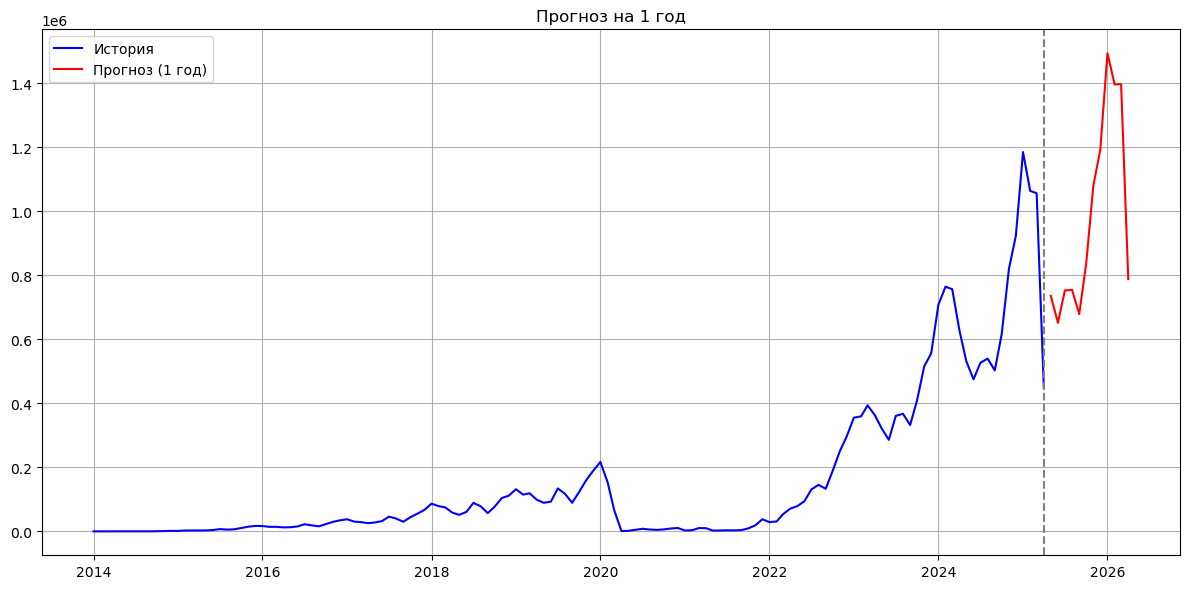

In [839]:
from prophet import Prophet
import matplotlib.pyplot as plt

# Агрегация по месяцам
monthly_data = data.resample('MS').sum().reset_index()
monthly_data.columns = ['ds', 'y']

# Обучаем модель
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
model.fit(monthly_data)

# Прогноз на 1 год
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

# Отделяем только прогнозные точки (12 новых месяцев)
last_date = monthly_data['ds'].max()
forecast_next_year = forecast[forecast['ds'] > last_date]

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(monthly_data['ds'], monthly_data['y'], label='История', color='blue')
plt.plot(forecast_next_year['ds'], forecast_next_year['yhat'], label='Прогноз (1 год)', color='red')
plt.axvline(x=last_date, color='gray', linestyle='--')
plt.title('Прогноз на 1 год')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Prophet daily for 90 days

In [843]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Подготовка данных
data = data.sort_index()
daily_data = data.resample('D').sum()

# 2. Разделение данных
test_size = 365
train_df = daily_data.iloc[:-test_size].reset_index()
test_df = daily_data.iloc[-test_size:].reset_index()

train_df.columns = ['ds', 'y']
test_df.columns = ['ds', 'y']

# 3. Обучение модели
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
model.fit(train_df)

# 4. Прогноз на 90 дней
future = model.make_future_dataframe(periods=test_size)
forecast = model.predict(future)

# 5. Выделим прогноз на последние 90 дней
forecast_test = forecast[['ds', 'yhat']].set_index('ds').loc[test_df['ds']]


09:29:58 - cmdstanpy - INFO - Chain [1] start processing
09:29:59 - cmdstanpy - INFO - Chain [1] done processing


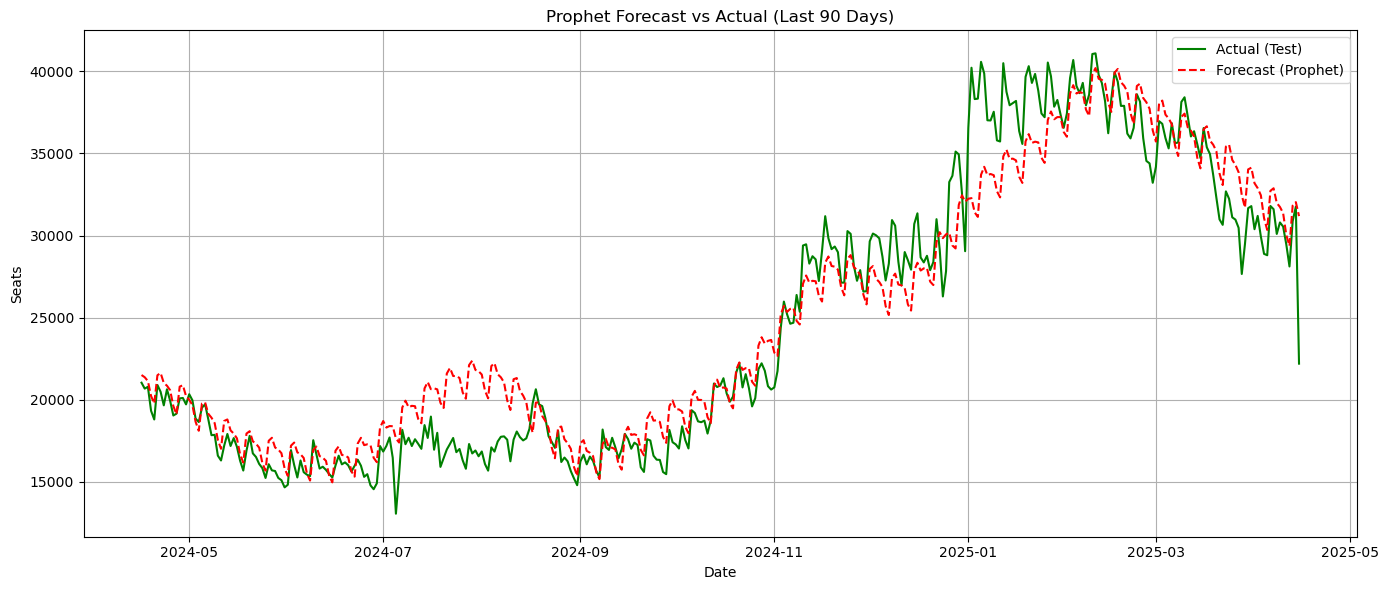

In [803]:
plt.figure(figsize=(14,6))
plt.plot(test_df['ds'], test_df['y'], label='Actual (Test)', color='green')
plt.plot(forecast_test.index, forecast_test['yhat'], label='Forecast (Prophet)', color='red', linestyle='--')
plt.title('Prophet Forecast vs Actual (Last 90 Days)')
plt.xlabel('Date')
plt.ylabel('Seats')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [805]:
mae = mean_absolute_error(test_df['y'], forecast_test['yhat'])
rmse = mean_squared_error(test_df['y'], forecast_test['yhat'], squared=False)
r2 = r2_score(test_df['y'], forecast_test['yhat'])

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")


MAE: 1694.62
RMSE: 2254.02
R²: 0.9297


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [807]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Убедимся, что индекс — datetime
data = data.sort_index()
daily_data = data.resample('D').sum()

# Разделение: последние 365 дней — test, остальное — train
test_size = 365
train_df = daily_data.iloc[:-test_size].reset_index()
test_df = daily_data.iloc[-test_size:].reset_index()

train_df.columns = ['ds', 'y']
test_df.columns = ['ds', 'y']


In [809]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
model.fit(train_df)

# Прогноз на те же даты, что и тест
future = model.make_future_dataframe(periods=test_size)
forecast = model.predict(future)

# Возьмем только последние 30 дней прогноза
forecast_test = forecast[['ds', 'yhat']].set_index('ds').loc[test_df['ds']]


19:25:17 - cmdstanpy - INFO - Chain [1] start processing
19:25:18 - cmdstanpy - INFO - Chain [1] done processing


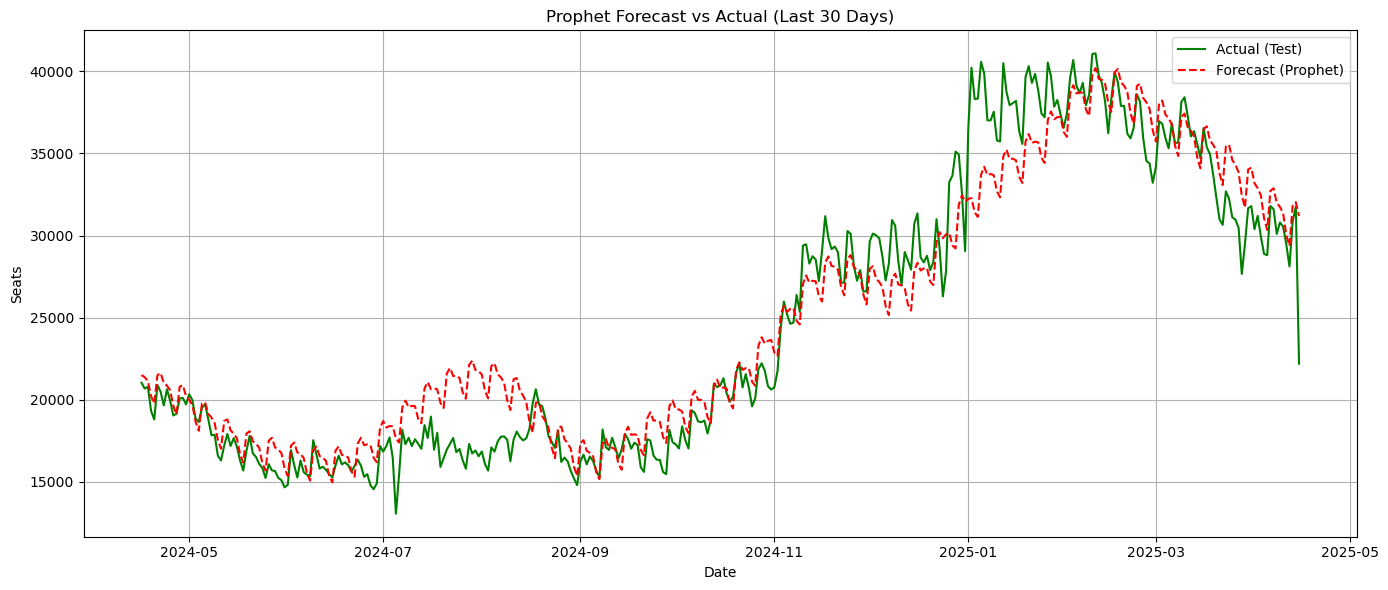

In [811]:
plt.figure(figsize=(14,6))
plt.plot(test_df['ds'], test_df['y'], label='Actual (Test)', color='green')
plt.plot(forecast_test.index, forecast_test['yhat'], label='Forecast (Prophet)', color='red', linestyle='--')
plt.title('Prophet Forecast vs Actual (Last 30 Days)')
plt.xlabel('Date')
plt.ylabel('Seats')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [799]:
from sklearn.metrics import r2_score
mae = mean_absolute_error(test_df['y'], forecast_test['yhat'])
rmse = mean_squared_error(test_df['y'], forecast_test['yhat'], squared=False)
r2 = r2_score(test_df['y'], forecast_test['yhat'])

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

R²: 0.6973
MAE: 1699.60
RMSE: 2098.56


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
